# 英國二手車市場 EDA：什麼驅動成交價格？

> **資料探索分析報告** · 視覺化：matplotlib + seaborn · 純 EDA（不建模）

## 0. 摘要與導讀（Executive Summary）

本報告分析英國二手車市場 **9 大品牌、約 9.7 萬筆**上架車輛資料，回答一個經銷商每天都要面對的問題：**該如何為一台二手車定價？哪些因素最能解釋價格？**

**五個關鍵發現（先講結論）：**

1. **引擎排量是最強的單一價格訊號**（與價格相關係數 ≈ **+0.65**）。排量每上升一級，價格帶整體上移。
2. **折舊真實且陡峭**：車齡與里程合計解釋了大部分的價格衰減（車齡 r ≈ −0.49、里程 r ≈ −0.42），且**折舊呈非線性**——新車前幾年掉價最快。
3. **品牌溢價明確分層**：Mercedes / BMW / Audi 三大德系豪華品牌中位價（約 £20k–22k）是 Vauxhall / Toyota（約 £10k）的兩倍以上；但部分溢價來自其**車型組成偏大排量**，並非純品牌光環。
4. **市場結構正在轉向**：柴油佔比逐年下滑，汽油與油電（Hybrid）逐步上升，反映英國排放政策與消費偏好的轉變。
5. **高油耗 ≠ 高價**：mpg 與價格呈**負相關**（r ≈ −0.34），因為省油的小車普遍較便宜——這是典型的「混淆變數」陷阱，提醒不可把相關當因果。

**閱讀方式**：第 1 章定義問題與分析框架；第 2–4 章交代資料整合、品質稽核與清理（嚴謹性基礎）；第 5–10 章依序回答五個子問題；第 11 章總結、限制與後續建模銜接。


## 1. 問題定義與分析框架

### 商業背景
英國二手車交易高度活絡，經銷商的核心痛點是**定價**：開太高賣不掉、壓庫存；開太低損失毛利。要科學定價，必須先理解「**價格由什麼決定**」。

### 核心問題
> 在英國二手車市場，**哪些因素驅動車輛的成交價格？這些因素的方向與強度為何？**

### 問題解構（5 個可驗證子問題）
| # | 子問題 | 對應章節 | 主要圖表 |
|---|--------|---------|---------|
| 1 | 品牌之間的價格差異有多大？是品牌本身還是規格組成造成？ | 第 6 章 | 排序箱型圖 + 品牌規格表 |
| 2 | 車齡與里程如何侵蝕價格？折舊是否非線性？ | 第 7 章 | 散佈圖 + 趨勢線 |
| 3 | 引擎、油耗、燃料/變速箱對價格的貢獻？ | 第 8 章 | 相關熱力圖 + 分組箱型圖 |
| 4 | 燃料類型的市場結構如何逐年演變？ | 第 9 章 | 逐年佔比堆疊圖 |
| 5 | 各因素如何共同決定價格？最強訊號是誰？ | 第 10 章 | 分面圖 + 關聯強度排序 |

### 方法論
對齊 **CRISP-DM** 標準流程：商業理解 → 資料理解 → 資料準備 → 探索分析。每一章先點明「**回答什麼問題**」，用圖表佐證，最後以一句「**洞察小結**」收束。所有清理步驟均印出影響筆數，確保**可稽核、可重現**。

> **給新手的提醒**：上面這 5 個子問題看起來像是憑空定義的，其實**不是**。實務上你會**先做第 5 章的「數據全貌掃描」，問題才從資料裡浮現**。這裡先列出來，只是為了讓報告好讀（先講要回答什麼）。真實的思考順序請見第 5 章結尾「從全貌到問題」。

### 起手式（框架 0）：拿到資料先別問問題，先看「全貌」

> 在進入下面兩個決策框架之前，要先破除一個新手迷思。

- **迷思**：分析 = 一拿到資料就知道要問什麼、馬上開始畫圖。
- **真相**：你一開始**不可能**問出好問題——因為你還不認識這份資料。

EDA 有兩種模式，實務上**交錯使用**：

- **由下而上（探索）**：先做「全貌掃描」把資料摸熟，讓**問題自己浮現**。← 新手、或面對陌生資料時，**從這裡開始**。
- **由上而下（驗證）**：心中已有商業問題或假設，直接拿資料驗證。

> **務實的順序**：`拿到資料 → 全貌掃描（廣度、機械式）→ 問題浮現 → 針對性深挖（深度、有方向）`
>
> 本報告第 1 章先列出 5 個子問題，只是為了「先講結論、方便閱讀」；它們其實是**第 5 章全貌掃描之後才浮現的**。新手請照真實順序走：**先翻到第 5 章做全貌掃描，再回頭看問題是怎麼長出來的。**


### 分析的思考脈絡：兩個決策框架（本報告的方法論）

> 多數人卡關不在「不會畫圖」，而在兩件事：**(1) 問題定義不夠利落**、**(2) 不知道該選哪張圖**。其實這兩者是**同一條思考脈絡**——**問題的型態，決定了呈現的方式**。後面每一章都會看到這兩個框架被實際套用。

---

#### 框架 A：從「商業問題」到「分析問題」（問題定義的階梯）

商業問題通常模糊、用利害關係人的語言（「怎麼定價？」）；分析問題必須**能用資料回答**。中間靠這個階梯往下拆：

```
商業問題（模糊、利害關係人語言）        例：「經銷商該怎麼為一台車定價？」
        │  問：要回答它，我需要知道什麼？
        ▼
分析主題（盤點候選的「因素」）          例：盤點欄位 → price 是 Y，其餘(品牌/年份/里程/
        │                                  排量/油耗/燃料/變速箱)都是候選的 X
        │  對每個因素問三件事：方向？強度？形狀？
        ▼
可驗證的分析子問題（綁定到資料欄位）    例：「車齡每增加 1 年，價格平均掉多少？是線性嗎？」
```

**好的分析子問題自我檢核（四個都要 Yes）：**
- **可量化**：答案是數字或明確的分布，不是形容詞。
- **可對照**：有比較基準（誰 vs 誰、前 vs 後）。
- **可證偽**：可能被資料推翻（不是「品牌很重要」這種一定對的廢話）。
- **對應欄位**：每個變數都能在資料裡找到。

> 本報告第 1 章的 5 個子問題，就是把「怎麼定價」沿這個階梯拆出來的結果。

---

#### 框架 B：從「分析問題」到「圖表」（選圖的決策）

**核心心法：先辨識問題屬於哪一「型態」，型態決定圖。** 幾乎所有 EDA 問題都落在這五類（Abela 圖表分類）：

| 問題型態 | 你在問什麼 | 主流圖 | 為什麼 |
|---------|-----------|--------|--------|
| **比較 Comparison** | 「誰比誰高/低？」 | 長條圖（比**單一數值**）／箱型圖（比**整個分布**） | 長度/位置最易被眼睛比較 |
| **分布 Distribution** | 「一個變數怎麼散開？」 | 直方圖／KDE／箱型圖／小提琴圖 | 看形狀、偏態、離群 |
| **關係 Relationship** | 「兩個數值如何連動？」 | 散點圖／回歸圖／相關熱力圖 | 看方向、強度、**形狀** |
| **組成 Composition** | 「部分如何佔整體？」 | 堆疊長條／堆疊面積圖 | 強調佔比加總 = 100% 的此消彼長 |
| **趨勢 Trend** | 「隨時間怎麼變？」 | 折線圖 | 連續線條表達時間連續性 |

**第二層修飾（選定型態後再微調）：**
- **變數的數量與型別**：數值×數值→散點；類別×數值→箱型；類別×類別→熱力圖。
- **樣本量**：大樣本散點會糊成一團（overplotting）→ 加透明度、抽樣、或改 hexbin。
- **偏態**：右偏的價格/里程 → 加**對數軸**才看得清。
- **維度加碼**：第 3 個變數用**顏色 (hue)**、第 4 個用**分面 (facet)** 塞進同一張圖。

> **一句話原則：圖表不是裝飾，是論證。** 每張圖都在回答一個明確的問題；**如果你說不出這張圖回答什麼問題，就不該畫它。**
>
> **兩個常見陷阱**：① 用「均值長條圖」比較群組——會**掩蓋分布與離群值**（豪華品牌內部價差極大，均值說謊）；② 濫用圓餅圖——人眼**比角度遠不如比長度**，超過 3 塊就難讀。

---

#### 把兩個框架串起來：本報告的選圖總表

| 子問題（框架 A 的產出） | 問題型態（框架 B 的判斷） | 選定圖表 | 章節 |
|------------------------|--------------------------|---------|------|
| 品牌之間價格差多少？ | 跨類別**比較分布** | 排序**箱型圖** | 第 6 章 |
| 車齡/里程如何侵蝕價格？ | 兩數值**關係**（看形狀） | **散點圖 + LOWESS** | 第 7 章 |
| 哪些規格與價格相關？ | 多變數**關係**概覽 | **相關熱力圖** + 分組箱型圖 | 第 8 章 |
| 燃料佔比怎麼演變？ | **組成**隨時間 | **堆疊面積圖** | 第 9 章 |
| 誰是最強價格訊號？ | **比較單一統計量** | 排序**長條圖** + 分面散點 | 第 10 章 |

> 注意第 6 章與第 10 章**同樣是「比較」，卻用了不同的圖**——因為一個比的是「分布」、一個比的是「單一數字」。這就是「問題型態決定圖」最精華的示範，讀到那兩章時請特別留意。


## 2. 資料載入與整合

### 整合策略（關鍵決策）
- **合併 9 個品牌檔**：Audi, BMW, Ford, Hyundai, Mercedes, Skoda, Toyota, Vauxhall, VW，每筆加上 `brand` 欄。
- **`hyundi.csv` 欄位正規化**：原始欄名為 `tax(£)`，rename 為 `tax`，否則合併後會產生兩個稅金欄。
- **明確排除 `cclass.csv` 與 `focus.csv`**：C-Class 是 Mercedes 子集、Focus 是 Ford 子集，併入會**重複計算**這兩個車型；且兩檔缺 `tax`、`mpg`，schema 不一致。
- **不納入 `unclean *.csv`**：那是課程資料清理練習素材，非本市場分析範圍。


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# --- global plotting style (consistency = rigor) ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.axisbelow": True,
})

# Snapshot year: the data was scraped circa 2020; car_age is measured from here.
SNAPSHOT_YEAR = 2020
GBP = "Price (GBP)"

DATA_DIR = Path("car_data")
BRAND_FILES = {
    "audi": "Audi", "bmw": "BMW", "ford": "Ford", "hyundi": "Hyundai",
    "merc": "Mercedes", "skoda": "Skoda", "toyota": "Toyota",
    "vauxhall": "Vauxhall", "vw": "VW",
}
print("pandas", pd.__version__, "| seaborn", sns.__version__)


pandas 2.2.2 | seaborn 0.13.2


In [2]:
# --- merge the 9 brand files into one market dataset ---
parts = []
for fname, brand in BRAND_FILES.items():
    d = pd.read_csv(DATA_DIR / f"{fname}.csv")
    d = d.rename(columns={"tax(£)": "tax"})   # normalise Hyundai's odd column
    d["brand"] = brand
    parts.append(d)

raw = pd.concat(parts, ignore_index=True)
assert len(raw) == sum(len(p) for p in parts), "row count mismatch on concat"
print(f"Merged raw dataset: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"(= sum of {len(parts)} brand files, no rows lost on concat)")
raw.head()


Merged raw dataset: 99,187 rows x 10 cols
(= sum of 9 brand files, no rows lost on concat)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


### 整合後資料字典

| 欄位 | 型別 | 說明 | 單位 |
|------|------|------|------|
| `brand` | str | 品牌（本次新增） | — |
| `model` | str | 車型 | — |
| `year` | int | 出廠年份 | 年 |
| `price` | int | **目標變數：上架價格** | £ |
| `transmission` | str | 變速箱（Manual / Automatic / Semi-Auto） | — |
| `mileage` | int | 行駛里程 | miles |
| `fuelType` | str | 燃料類型（Petrol / Diesel / Hybrid…） | — |
| `tax` | int | 道路稅 | £/年 |
| `mpg` | float | 油耗（每加侖英里數，越高越省） | mpg |
| `engineSize` | float | 引擎排量 | L |


## 3. 資料品質稽核（Data Quality Audit）

> **回答的問題**：在分析之前，這份資料可信嗎？有哪些缺失、重複與不合理值需要處理？

嚴謹的 EDA**先稽核、後分析**。本章不做清理，只「揭露」問題，下一章才動手。


In [3]:
# structural overview
raw.info()
print("\n--- duplicate full rows:", raw.duplicated().sum())
print("--- missing values per column ---")
print(raw.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  object 
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  object 
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  object 
 6   tax           99187 non-null  int64  
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   brand         99187 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.6+ MB

--- duplicate full rows: 1475
--- missing values per column ---
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64


In [4]:
# numeric summary exposes impossible / suspicious values
raw.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]


,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6


稽核 `describe()` 立刻暴露幾個**不可能或可疑的值**，逐一用圖佐證：
- `year` 最大值遠超 2020（未來年份，明顯錯誤）
- `engineSize` 最小值為 **0**（不存在 0L 引擎）
- `mpg` 最大值異常高（非油電車不該有）


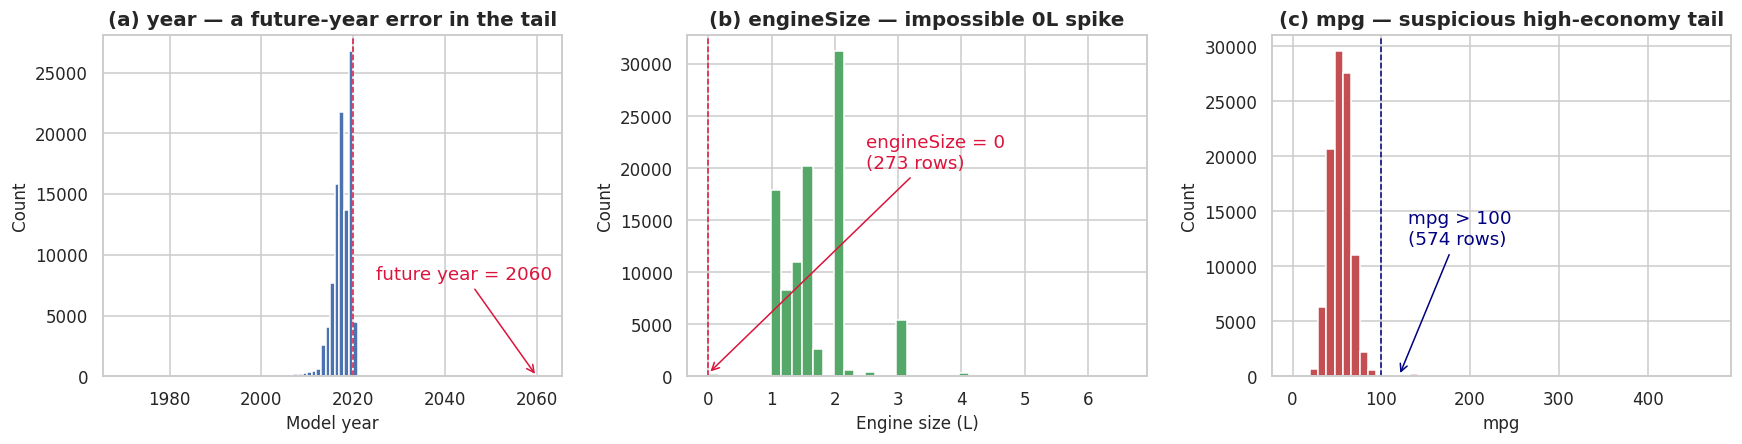

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) year: a future-year outlier hides in the tail
axes[0].hist(raw["year"], bins=range(raw["year"].min(), raw["year"].max() + 2),
             color="#4C72B0", edgecolor="white")
axes[0].axvline(SNAPSHOT_YEAR, color="crimson", ls="--", lw=1)
axes[0].annotate(f"future year = {raw['year'].max()}",
                 xy=(raw["year"].max(), 1), xytext=(2025, 8000),
                 arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
axes[0].set(title="(a) year — a future-year error in the tail",
            xlabel="Model year", ylabel="Count")

# (b) engineSize: a spike at 0 = impossible engine
axes[1].hist(raw["engineSize"], bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(0, color="crimson", ls="--", lw=1)
axes[1].annotate(f"engineSize = 0\n({(raw['engineSize'] == 0).sum()} rows)",
                 xy=(0, (raw["engineSize"] == 0).sum()), xytext=(2.5, 20000),
                 arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
axes[1].set(title="(b) engineSize — impossible 0L spike",
            xlabel="Engine size (L)", ylabel="Count")

# (c) mpg: long right tail of suspicious high-economy values
axes[2].hist(raw["mpg"], bins=50, color="#C44E52", edgecolor="white")
axes[2].axvline(100, color="navy", ls="--", lw=1)
axes[2].annotate(f"mpg > 100\n({(raw['mpg'] > 100).sum()} rows)",
                 xy=(120, 50), xytext=(130, 12000),
                 arrowprops=dict(arrowstyle="->", color="navy"), color="navy")
axes[2].set(title="(c) mpg — suspicious high-economy tail",
            xlabel="mpg", ylabel="Count")

plt.tight_layout()
plt.show()


> **洞察小結**：資料整體結構完整、缺失值極少，但藏有 (a) 未來年份、(b) 0L 引擎、(c) 異常油耗三類不合理值，加上約 1.5k 筆完全重複列。下一章用明確規則清理，並印出每步影響筆數。


## 4. 資料清理（可重現）

> **回答的問題**：用什麼明確規則把資料修乾淨？每步移除多少筆？

清理原則：**保守、透明、可稽核**。每一步都印出 before/after 筆數；只移除「物理上不可能」的列，可疑但可能合理的值（如高 mpg 的插電油電車）保留並標記。


In [6]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    '''Apply documented, auditable cleaning rules; print row impact of each.'''
    n0 = len(df)
    out = df.copy()

    # rule 1: drop exact duplicate listings
    out = out.drop_duplicates()
    print(f"1. drop exact duplicates      : -{n0 - len(out):>5,}  -> {len(out):,}")

    # rule 2: drop future model years (physically impossible)
    n = len(out); out = out[out["year"] <= SNAPSHOT_YEAR]
    print(f"2. drop year > {SNAPSHOT_YEAR}          : -{n - len(out):>5,}  -> {len(out):,}")

    # rule 3: drop 0L engines (data error, not a real car)
    n = len(out); out = out[out["engineSize"] > 0]
    print(f"3. drop engineSize == 0       : -{n - len(out):>5,}  -> {len(out):,}")

    # derived feature: car age from the data snapshot year
    out["car_age"] = SNAPSHOT_YEAR - out["year"]

    # flag (do NOT drop) suspicious high-economy rows for transparency
    out["mpg_suspicious"] = out["mpg"] > 100

    print(f"\nfinal: {len(out):,} rows kept ({len(out) / n0:.1%} of raw), "
          f"{out['mpg_suspicious'].sum():,} rows flagged mpg>100 (kept)")
    return out


df = clean(raw)


1. drop exact duplicates      : -1,475  -> 97,712
2. drop year > 2020          : -    1  -> 97,711
3. drop engineSize == 0       : -  268  -> 97,443

final: 97,443 rows kept (98.2% of raw), 528 rows flagged mpg>100 (kept)


In [7]:
# post-clean snapshot
print("Numeric columns after cleaning:")
df[["price", "year", "car_age", "mileage", "tax", "mpg", "engineSize"]].describe().T.round(1)


Numeric columns after cleaning:


,count,mean,std,min,25%,50%,75%,max
price,97443.0,16773.7,9869.9,450.0,9999.0,14471.0,20750.0,159999.0
year,97443.0,2017.1,2.1,1970.0,2016.0,2017.0,2019.0,2020.0
car_age,97443.0,2.9,2.1,0.0,1.0,3.0,4.0,50.0
mileage,97443.0,23224.5,21069.2,1.0,7672.0,17679.0,32500.0,323000.0
tax,97443.0,120.2,63.3,0.0,125.0,145.0,145.0,580.0
mpg,97443.0,55.1,14.1,0.3,47.1,54.3,62.8,470.8
engineSize,97443.0,1.7,0.6,0.6,1.2,1.6,2.0,6.6


> **洞察小結**：清理後保留約 **97.4k 筆（原始的 98.2%）**，數據損失極小。新增衍生特徵 `car_age`（= 2020 − 年份）作為折舊分析的核心軸。可疑高 mpg 列以旗標保留而非刪除，兼顧透明與資料完整。


## 5. 數據全貌掃描與單變量分析（先了解資料的長相）

> **回答的問題**：每個變數本身長什麼樣？目標變數 `price` 的分布形狀如何？

理解單一變數的分布是後續所有雙變量分析的前提——尤其要先看清目標變數 `price` 是否偏態（這決定該用線性還是對數視角）。


### 先看全貌：數據全貌掃描（Data Profiling）

> **新手最常犯的錯：拿到資料就急著畫圖、急著問問題。** 但你還不認識這份資料，怎麼可能問出好問題？
>
> **正確的第一步是「全貌掃描」**——用一套**固定的清單**，機械式地把資料的「長相」摸清楚。這一步**不需要靈感、人人都能做**，而且做完之後，值得深挖的問題會**自己浮現**。

**全貌掃描清單（拿到任何資料都先跑這幾項）：**

| 看什麼 | 用什麼 | 它告訴你 |
|--------|--------|---------|
| 規模 | `df.shape` | 幾筆、幾欄，樣本夠不夠 |
| 欄位型別 | `df.dtypes` | 數值 or 類別——決定能做什麼分析、選什麼圖 |
| 缺失 | `df.isna()` | 哪些欄不可靠 |
| 數值範圍 | `df.describe()` | 量級、離群、不合理值 |
| 類別分布 | `value_counts()` | 有哪些類別、是否嚴重不平衡 |
| 唯一值數 | `nunique()` | 是 ID 還是可分析的類別 |
| 目標變數 | 單獨看 `price` | 它的量級與分布形狀（決定要不要對數軸） |

下面用**一張總表一次掃完全部欄位**——這就是拿到任何資料該跑的第一段程式碼：


In [8]:
# === 數據全貌掃描：拿到（清理後的）資料，第一件事就是跑這張總表 ===
def profile(data: pd.DataFrame) -> pd.DataFrame:
    """One-shot holistic snapshot of every column: dtype, missing%, cardinality,
    and either a numeric range or the top categories. The first thing to run on
    ANY new dataset — it is mechanical, needs no insight, and surfaces questions."""
    rows = {}
    for col in data.columns:
        s = data[col]
        rec = {"dtype": str(s.dtype),
               "missing%": round(s.isna().mean() * 100, 1),
               "n_unique": int(s.nunique())}
        if pd.api.types.is_numeric_dtype(s):
            lo, hi, med = float(s.min()), float(s.max()), float(s.median())
            rec["range / top categories"] = f"{lo:g} … {hi:g}  (median {med:g})"
        else:
            top = s.value_counts().head(3)
            rec["range / top categories"] = ",  ".join(f"{k} ({v:,})" for k, v in top.items())
        rows[col] = rec
    return pd.DataFrame(rows).T

print(f"資料規模 shape : {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"目標變數 price : median £{df['price'].median():,.0f} | "
      f"mean £{df['price'].mean():,.0f} | "
      f"range £{df['price'].min():,.0f}-£{df['price'].max():,.0f}")
profile(df)


資料規模 shape : 97,443 rows x 12 cols
目標變數 price : median £14,471 | mean £16,774 | range £450-£159,999


,dtype,missing%,n_unique,range / top categories
model,object,0.0,194,"Fiesta (6,489), Golf (4,794), Focus (4,544)"
year,int64,0.0,26,1970 … 2020 (median 2017)
price,int64,0.0,13215,450 … 159999 (median 14471)
transmission,object,0.0,4,"Manual (55,346), Semi-Auto (22,296), Automat..."
mileage,int64,0.0,42167,1 … 323000 (median 17679)
fuelType,object,0.0,5,"Petrol (53,823), Diesel (40,350), Hybrid (3,..."
tax,int64,0.0,47,0 … 580 (median 145)
mpg,float64,0.0,208,0.3 … 470.8 (median 54.3)
engineSize,float64,0.0,39,0.6 … 6.6 (median 1.6)
brand,object,0.0,9,"Ford (17,759), VW (14,878), Vauxhall (13,225)"


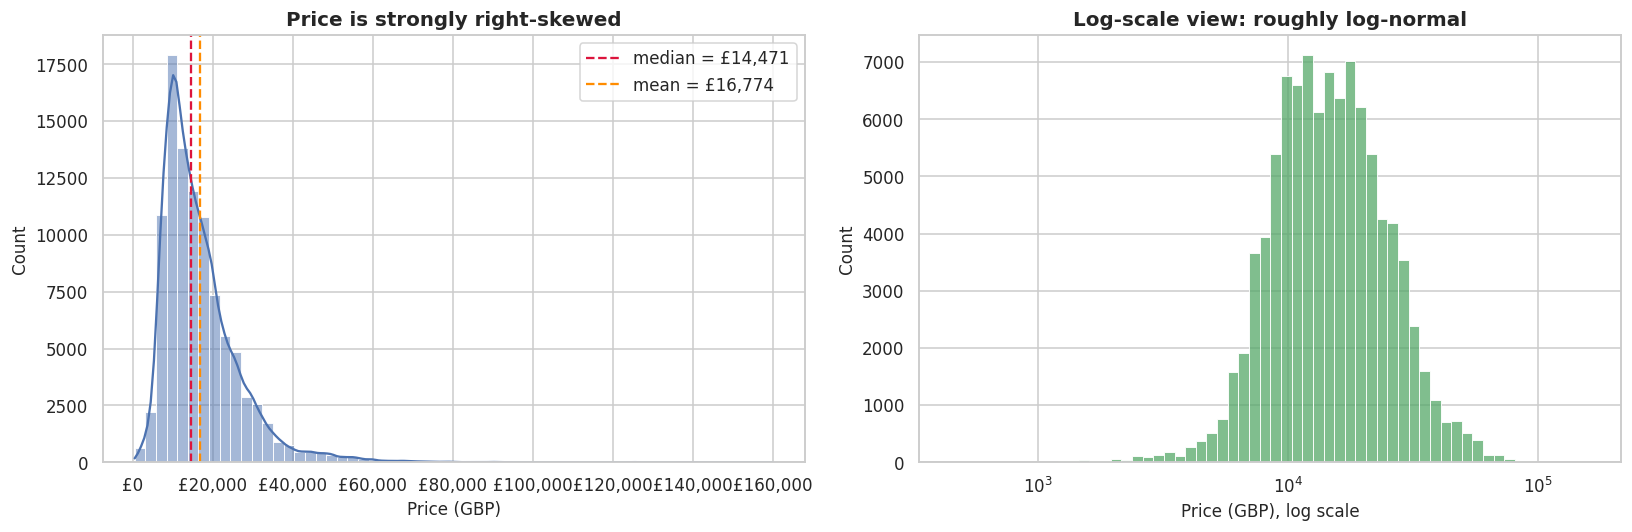

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["price"], bins=60, kde=True, color="#4C72B0", ax=axes[0])
axes[0].axvline(df["price"].median(), color="crimson", ls="--",
                label=f"median = £{df['price'].median():,.0f}")
axes[0].axvline(df["price"].mean(), color="darkorange", ls="--",
                label=f"mean = £{df['price'].mean():,.0f}")
axes[0].set(title="Price is strongly right-skewed", xlabel=GBP, ylabel="Count")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
axes[0].legend()

sns.histplot(df["price"], bins=60, color="#55A868", ax=axes[1], log_scale=(True, False))
axes[1].set(title="Log-scale view: roughly log-normal",
            xlabel=GBP + ", log scale", ylabel="Count")

plt.tight_layout(); plt.show()


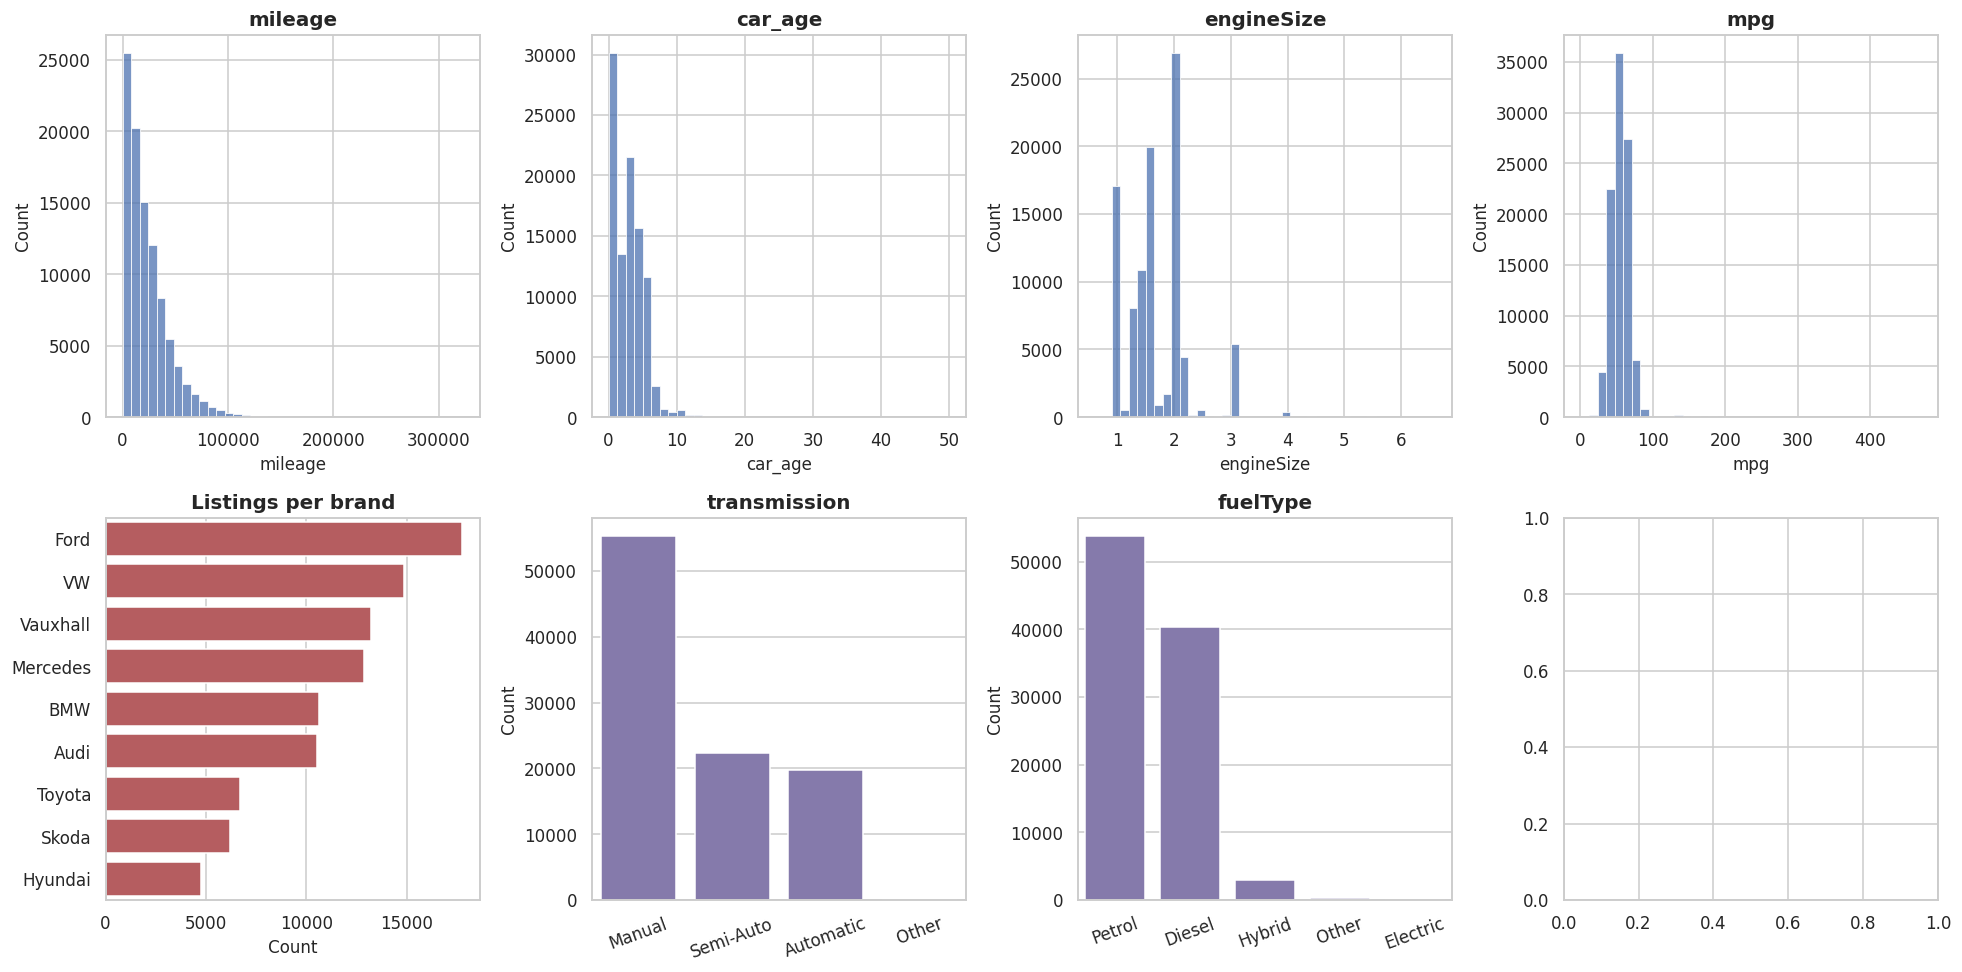

In [10]:
# numeric distributions + categorical counts in one panel
num_cols = ["mileage", "car_age", "engineSize", "mpg"]
cat_cols = ["brand", "transmission", "fuelType"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, col in zip(axes[0], num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set(title=f"{col}", xlabel=col, ylabel="Count")

sns.countplot(data=df, y="brand", order=df["brand"].value_counts().index,
              ax=axes[1, 0], color="#C44E52")
axes[1, 0].set(title="Listings per brand", xlabel="Count", ylabel="")

for ax, col in zip(axes[1, 1:], cat_cols[1:]):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index,
                  ax=ax, color="#8172B3")
    ax.set(title=col, xlabel="", ylabel="Count")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()


> **洞察小結**：`price` 明顯**右偏**（mean > median），取對數後近似常態——後續涉及價格的趨勢圖會輔以對數刻度。里程與車齡同樣右偏（多數是低齡低里程的近新車）。品牌樣本以 Ford / VW 最多，燃料以 Diesel / Petrol 為主、Hybrid 仍少。


### 從「全貌」到「問題」：5 個子問題是怎麼浮現的

> 這是最關鍵的一步——**問題不是憑空定義的，是看完全貌後「長出來」的**。回顧剛剛的全貌掃描與單變量分布，我們注意到幾件事，每一件都自然引出一個值得深挖的問題：

| 全貌掃描看到的現象 | 自然浮現的問題 | → 章節 |
|-------------------|---------------|-------|
| `price` 右偏、從 £450 一路到 £16 萬，跨度極大 | 是什麼把價格拉開這麼大？品牌嗎？ | 第 6 章 |
| 有 `year`、`mileage` 兩個「使用程度」欄，且都右偏（多為近新車） | 車齡與里程如何侵蝕價格？折舊是什麼形狀？ | 第 7 章 |
| `engineSize`、`mpg`、`tax` 等多個數值規格欄 | 哪個規格最能解釋價格？ | 第 8 章 |
| `fuelType` 含 Diesel/Petrol/Hybrid，且 `year` 橫跨多年 | 燃料結構是否隨年代改變？ | 第 9 章 |
| 因素很多、彼此可能交纏（豪華品牌也大排量…） | 綜合來看，誰才是最強訊號？ | 第 10 章 |

> **這才是 EDA 的真實節奏**：全貌掃描（廣度、機械式、人人能做）→ 問題浮現 → 針對性深挖（深度、有方向）。**前者餵養後者。** 下面第 6–10 章，就依序回答這 5 個從資料裡長出來的問題。


## 6. 子問題一：品牌溢價

> **回答的問題**：不同品牌的價格差多少？是「品牌光環」還是「車型規格組成」造成的？


> **【選圖推理】為什麼是排序箱型圖？**
> - **問題型態**：跨品牌「**比較**」——但我們要比的是**整個價格分布**，不是單一均值。
> - **為何箱型圖**：一次呈現中位數、四分位距與離群，揭露「豪華品牌內部價差極大」這個均值會掩蓋的事實。
> - **為何依中位數排序**：排序後高低一目了然，眼睛沿著遞增方向掃即可，不必來回比對。
> - **反例**：若改用「均值長條圖」，會抹平分布、被極端高價車拉高，做出誤導性的定價結論。


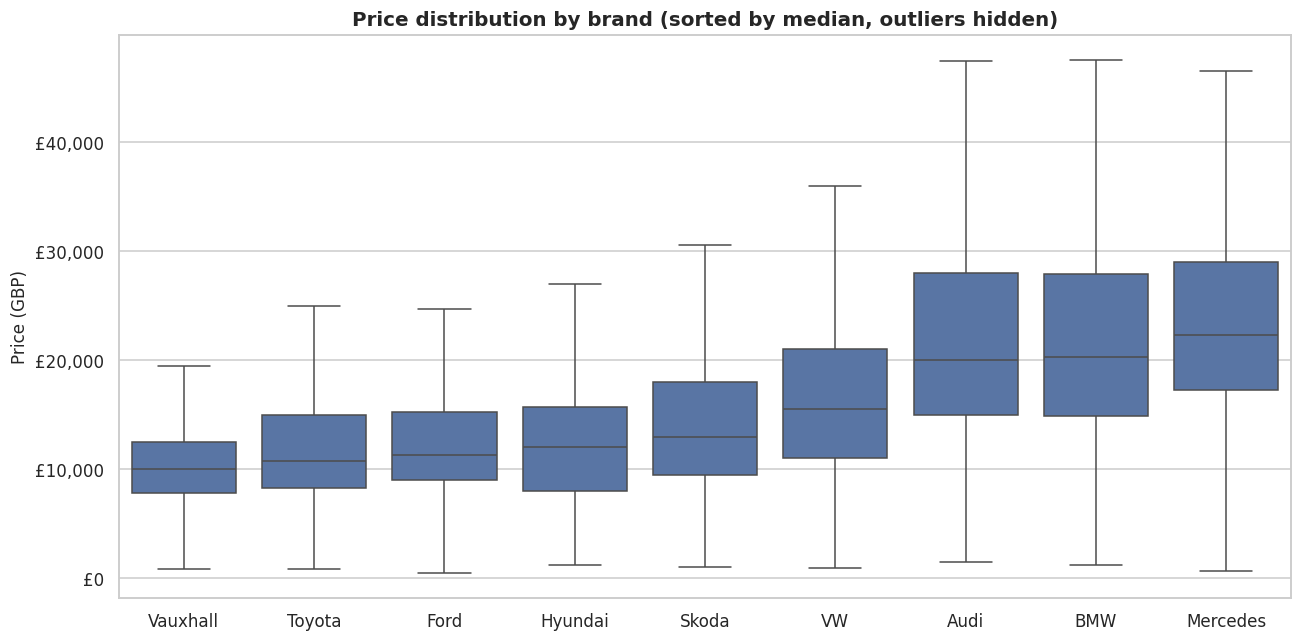

In [11]:
order = df.groupby("brand")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="brand", y="price", order=order, showfliers=False, ax=ax)
ax.set(title="Price distribution by brand (sorted by median, outliers hidden)",
       xlabel="", ylabel=GBP)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout(); plt.show()


          median_price  median_engine  median_age      n
brand                                                   
Mercedes       22299.0            2.0         2.0  12848
BMW            20330.0            2.0         3.0  10617
Audi           20000.0            2.0         3.0  10513
VW             15491.5            1.6         3.0  14878
Skoda          12998.0            1.4         2.0   6183
Hyundai        11995.0            1.6         3.0   4727
Ford           11290.0            1.2         3.0  17759
Toyota         10798.0            1.5         3.0   6693
Vauxhall        9998.0            1.4         3.0  13225


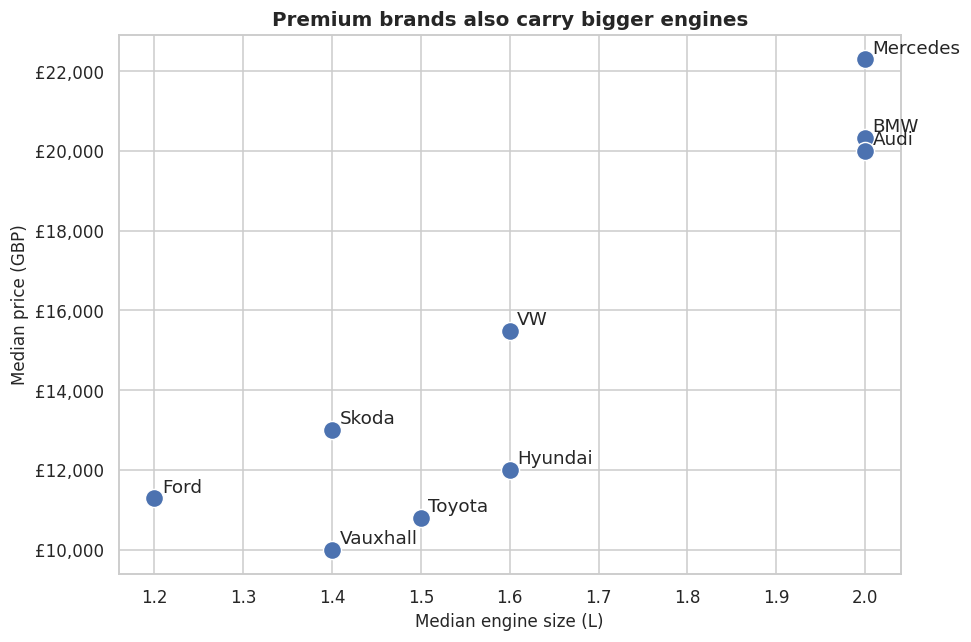

In [12]:
# is the premium just bigger engines? compare price vs engineSize per brand
brand_tbl = (df.groupby("brand")
             .agg(median_price=("price", "median"),
                  median_engine=("engineSize", "median"),
                  median_age=("car_age", "median"),
                  n=("price", "size"))
             .sort_values("median_price", ascending=False))
print(brand_tbl.round(2))

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=brand_tbl, x="median_engine", y="median_price",
                s=140, color="#4C72B0", ax=ax)
for b, r in brand_tbl.iterrows():
    ax.annotate(b, (r["median_engine"], r["median_price"]),
                xytext=(5, 4), textcoords="offset points")
ax.set(title="Premium brands also carry bigger engines",
       xlabel="Median engine size (L)", ylabel="Median price (GBP)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout(); plt.show()


> **洞察小結**：品牌價格分層清楚——Mercedes / BMW / Audi（中位約 £20k+）明顯高於 Vauxhall / Toyota（約 £10k）。但右圖顯示豪華品牌的**中位引擎排量也較大**，亦即溢價有一部分來自規格組成、而非純品牌光環。要分離「純品牌效應」需在控制排量/車齡後比較（留待建模階段）。


## 7. 子問題二：折舊曲線

> **回答的問題**：車齡與里程如何侵蝕價格？折舊是線性還是非線性？


> **【選圖推理】為什麼是散點圖 + LOWESS？**
> - **問題型態**：兩個數值變數（車齡/里程 vs 價格）的「**關係**」，而且我們關心的是**形狀**——折舊是直線還是曲線？
> - **為何加 LOWESS**：局部加權平滑能讓**非線性**現形（前期陡、後期緩）；只報一個相關係數 −0.49 會完全錯過這個轉折，而轉折正是定價關鍵。
> - **第二層修飾**：近 10 萬筆散點會糊成一團 → **抽樣 6000 筆 + 透明度 0.15** 解決 overplotting；折舊圖搭配**對數價格軸**讓曲線線性化、方便比較品牌斜率。


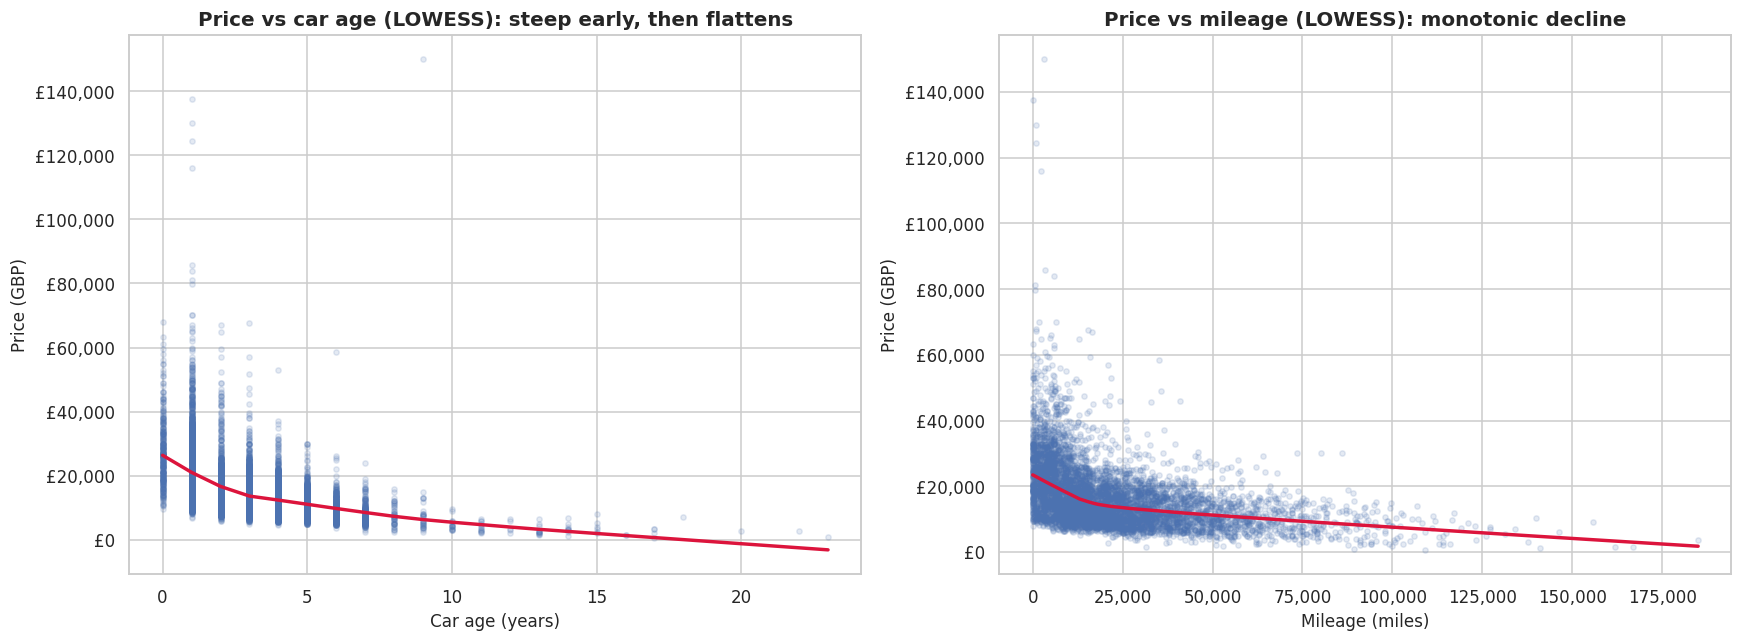

In [13]:
samp = df.sample(6000, random_state=42)   # subsample to keep scatter readable

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=samp, x="car_age", y="price", ax=axes[0],
            scatter_kws=dict(alpha=0.15, s=12),
            line_kws=dict(color="crimson"), lowess=True)
axes[0].set(title="Price vs car age (LOWESS): steep early, then flattens",
            xlabel="Car age (years)", ylabel=GBP)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))

sns.regplot(data=samp, x="mileage", y="price", ax=axes[1],
            scatter_kws=dict(alpha=0.15, s=12),
            line_kws=dict(color="crimson"), lowess=True)
axes[1].set(title="Price vs mileage (LOWESS): monotonic decline",
            xlabel="Mileage (miles)", ylabel=GBP)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout(); plt.show()


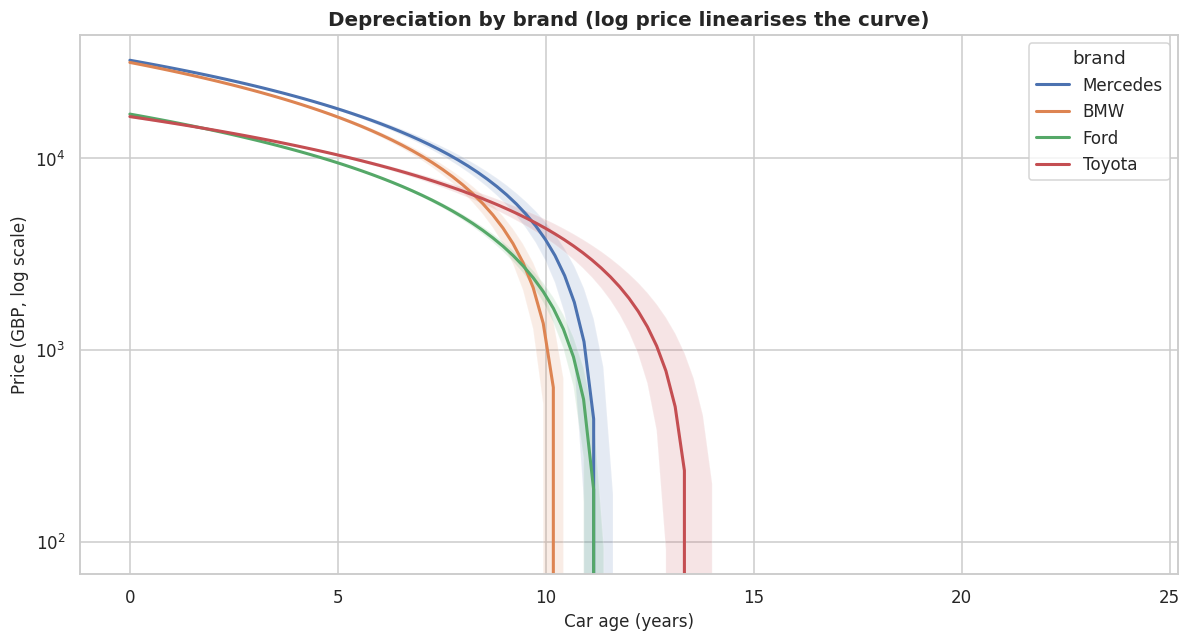

In [14]:
# log-price linearises depreciation; compare slopes across a few brands
fig, ax = plt.subplots(figsize=(11, 6))
focus_brands = ["Mercedes", "BMW", "Ford", "Toyota"]
for b in focus_brands:
    sub = df[df["brand"] == b]
    sns.regplot(data=sub, x="car_age", y="price", scatter=False,
                logx=False, ax=ax, label=b,
                line_kws=dict(lw=2))
ax.set_yscale("log")
ax.set(title="Depreciation by brand (log price linearises the curve)",
       xlabel="Car age (years)", ylabel="Price (GBP, log scale)")
ax.legend(title="brand")
plt.tight_layout(); plt.show()


> **洞察小結**：折舊**真實且非線性**——LOWESS 曲線在前幾年最陡（新車落地掉價最快），之後趨緩。里程則呈單調遞減。對數價格下各品牌折舊斜率不同：豪華品牌起點高、絕對掉價金額也大。車齡與里程高度相關（兩者都代表「用了多久」），建模時需留意共線性。


## 8. 子問題三：規格驅動

> **回答的問題**：引擎、油耗、燃料與變速箱類型，對價格各有多少貢獻？


> **【選圖推理】一個章節、兩種問題、兩種圖。**
> - **數值因素 → 相關熱力圖**：問「哪些數值規格與價格相關」屬**多變數關係概覽**，熱力圖用顏色一次編碼所有配對的方向與強度，比逐張散點高效。
> - **類別因素 → 分組箱型圖**：問「燃料/變速箱如何影響價格」屬**類別對數值的分布比較**，箱型圖最直接。
> - **教學重點**：同一個「規格驅動」大哉問，拆成數值與類別兩種子型態後，各自對應到不同的主流圖——**先分型態，再選圖**。


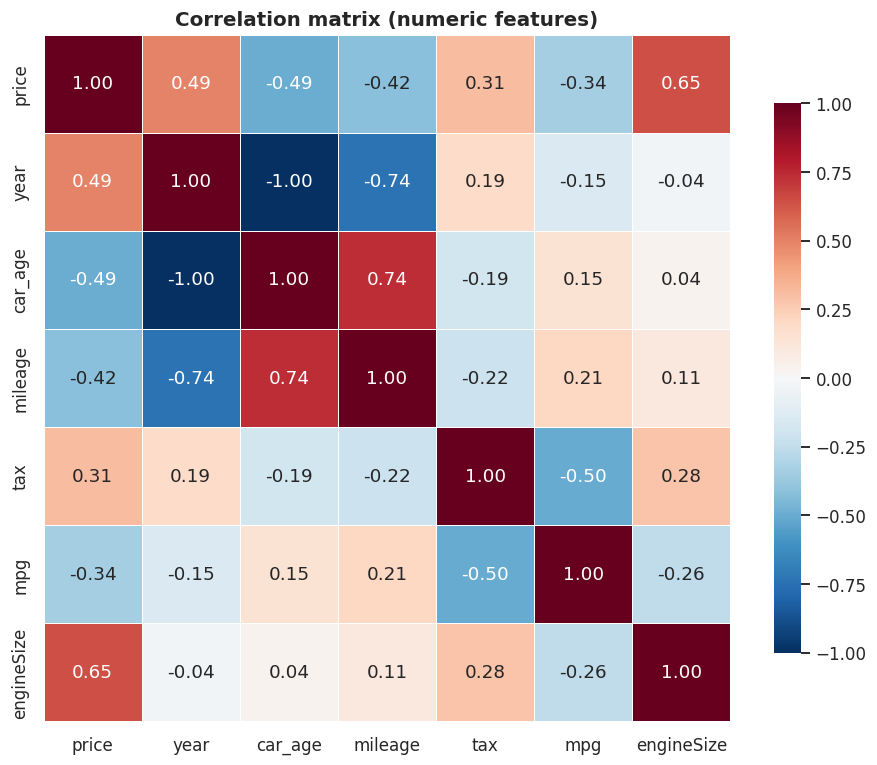

Correlation with price (sorted):
engineSize    0.648
year          0.494
tax           0.307
mpg          -0.341
mileage      -0.418
car_age      -0.494
Name: price, dtype: float64


In [15]:
num = ["price", "year", "car_age", "mileage", "tax", "mpg", "engineSize"]
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.5, cbar_kws=dict(shrink=.8), ax=ax)
ax.set(title="Correlation matrix (numeric features)")
plt.tight_layout(); plt.show()

print("Correlation with price (sorted):")
print(corr["price"].drop("price").sort_values(ascending=False).round(3))


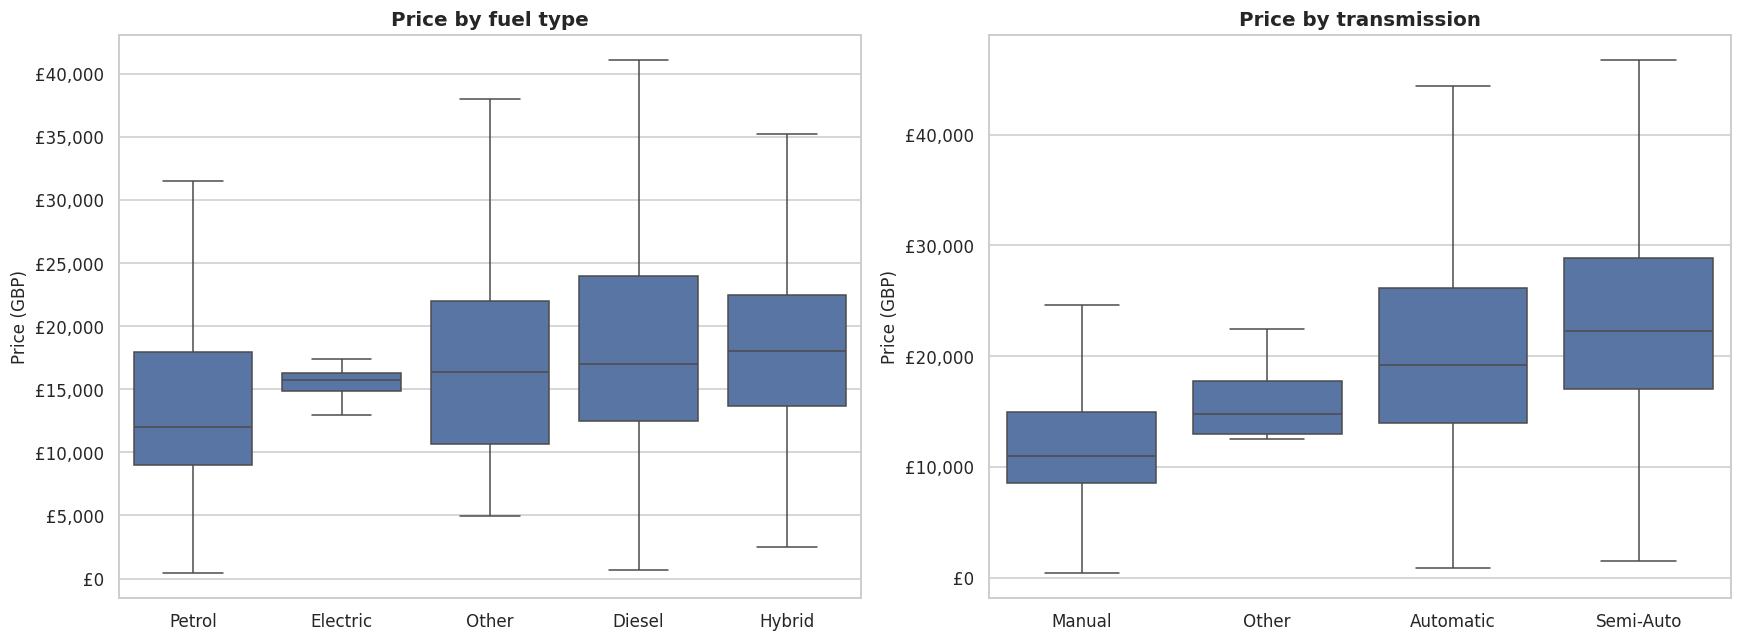

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x="fuelType", y="price",
            order=df.groupby("fuelType")["price"].median().sort_values().index,
            showfliers=False, ax=axes[0])
axes[0].set(title="Price by fuel type", xlabel="", ylabel=GBP)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))

sns.boxplot(data=df, x="transmission", y="price",
            order=df.groupby("transmission")["price"].median().sort_values().index,
            showfliers=False, ax=axes[1])
axes[1].set(title="Price by transmission", xlabel="", ylabel=GBP)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))

plt.tight_layout(); plt.show()


> **洞察小結**：`engineSize` 是**最強的正向價格訊號（r ≈ +0.65）**。`mpg` 與價格**負相關（r ≈ −0.34）**——並非「省油就便宜」的因果，而是省油的小排量平價車拉低了關聯（典型混淆變數）。燃料上 Hybrid/Diesel 中位價高於 Petrol；變速箱上 Semi-Auto/Automatic 高於 Manual，但這同樣與「自排多見於高階大車」交纏。


## 9. 子問題四：市場結構演變

> **回答的問題**：燃料類型的市場佔比如何逐年變化？反映了什麼趨勢？


> **【選圖推理】為什麼是堆疊面積圖？**
> - **問題型態**：燃料類型佔比「**組成**」如何「隨時間」演變——是 Composition + Trend 的綜合。
> - **為何堆疊面積**：強調「**佔比加總 = 100%** 的此消彼長」（柴油退、汽油與油電進），總和守恆的視覺感最強。
> - **反例**：若畫三條獨立折線，讀者難一眼看出「誰吃掉誰的市佔」，也看不出總和關係。


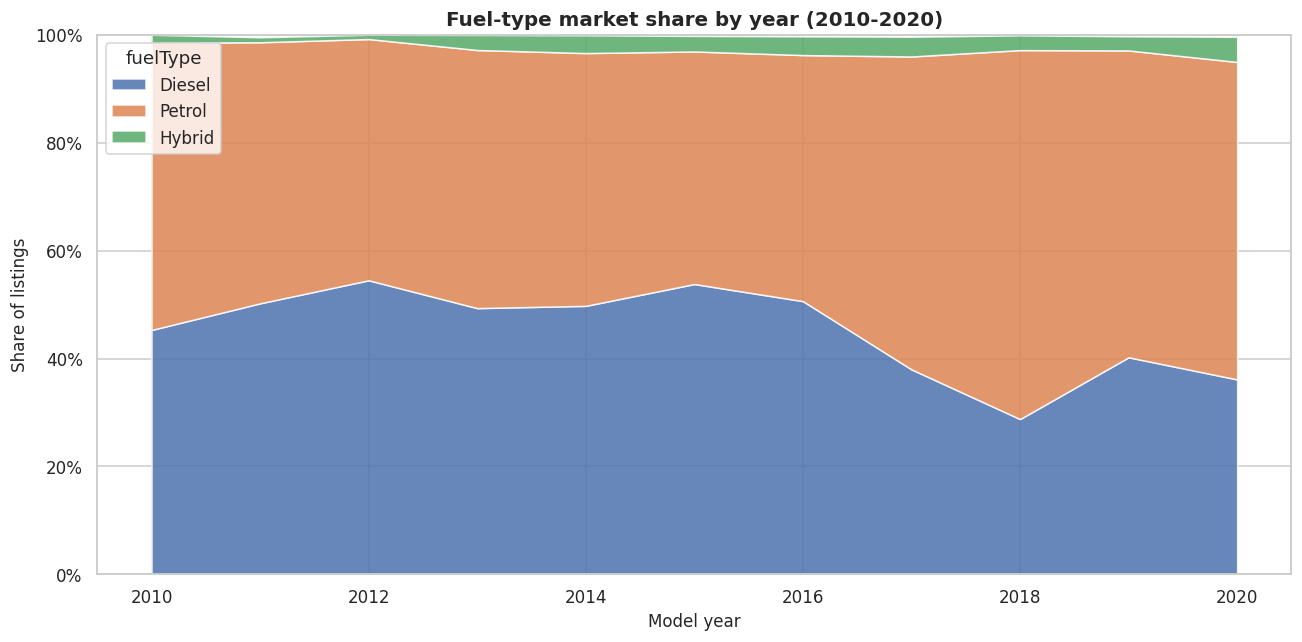

In [17]:
# yearly fuel-type share (focus on the well-populated 2010-2020 window)
win = df[(df["year"] >= 2010) & (df["year"] <= 2020)]
share = pd.crosstab(win["year"], win["fuelType"], normalize="index")
keep = ["Diesel", "Petrol", "Hybrid"]
share = share[[c for c in keep if c in share.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(share.index, [share[c] for c in share.columns],
             labels=share.columns, alpha=0.85)
ax.set(title="Fuel-type market share by year (2010-2020)",
       xlabel="Model year", ylabel="Share of listings", ylim=(0, 1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="upper left", title="fuelType")
plt.tight_layout(); plt.show()


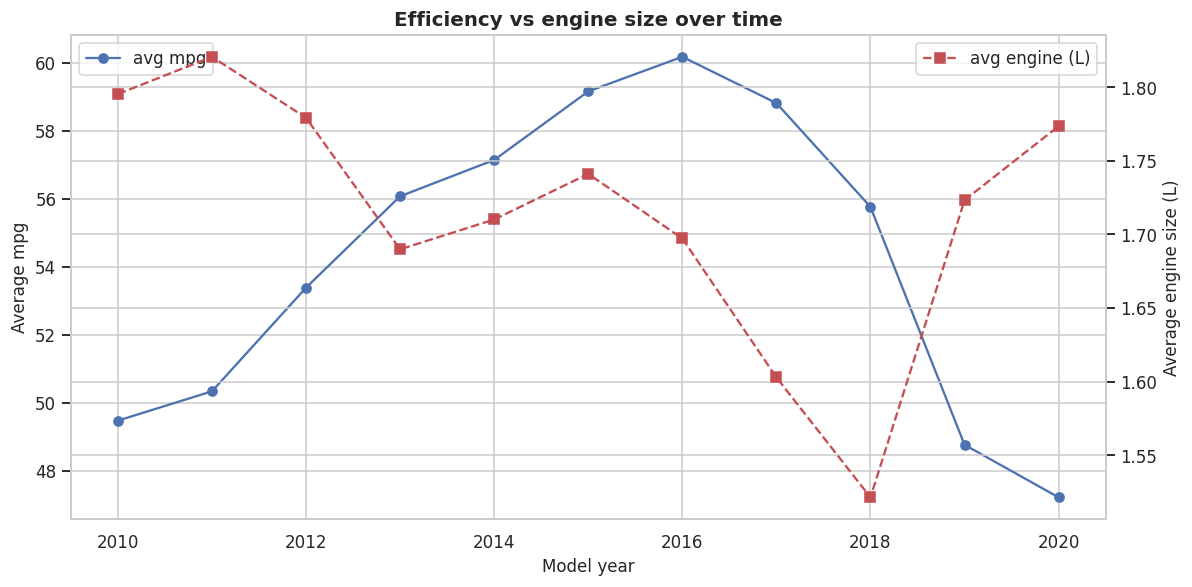

In [18]:
# parallel trend: average mpg and engine size are creeping over time
trend = win.groupby("year").agg(avg_mpg=("mpg", "mean"),
                                avg_engine=("engineSize", "mean"))
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax2 = ax1.twinx()
ax1.plot(trend.index, trend["avg_mpg"], "o-", color="#4C72B0", label="avg mpg")
ax2.plot(trend.index, trend["avg_engine"], "s--", color="#C44E52", label="avg engine (L)")
ax1.set(title="Efficiency vs engine size over time",
        xlabel="Model year", ylabel="Average mpg")
ax2.set_ylabel("Average engine size (L)")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()


> **洞察小結**：柴油佔比自高點逐年下滑，汽油與 Hybrid 緩步上升——與英國 2010 年代後的排放政策與消費偏好轉變一致。平均 mpg 與引擎排量的時間走勢也透露車型結構的演化。這提醒我們：年份不只是折舊軸，也夾帶了「車種世代」的市場效應。


## 10. 子問題五：綜合定價畫像

> **回答的問題**：把因素放在一起看，誰是最強的價格訊號？整體定價結構長什麼樣？


> **【選圖推理】同樣是「比較」，這次為何改用長條圖？**
> - **問題型態**：比較各特徵與價格的關聯強度——但這次比的是**單一統計量（相關係數）**，不是分布。
> - **為何長條圖**：比單一數值時，長度是最精準的視覺編碼；用顏色區分正/負向、由強到弱排序，最強訊號一眼看出。
> - **對照第 6 章**：第 6 章「比較分布」用**箱型圖**、這裡「比較單一數字」用**長條圖**——**這就是「問題型態決定圖」的核心**。
> - **第二張圖（分面散點）**：示範**維度加碼**——用顏色 (車齡) + 分面 (變速箱) 在一張圖塞進 4 個變數，回答「多因素如何共同決定價格」。


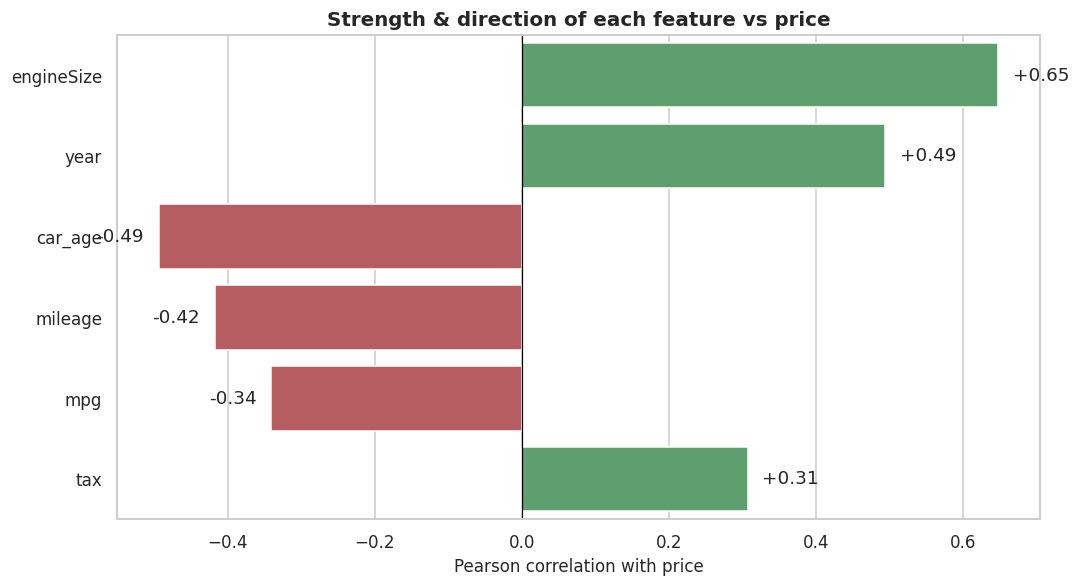

In [19]:
# strength of association of each feature with price, in one ranked bar
num_feats = ["engineSize", "year", "tax", "mpg", "mileage", "car_age"]
strength = df[num_feats + ["price"]].corr()["price"].drop("price")
strength = strength.reindex(strength.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#55A868" if v > 0 else "#C44E52" for v in strength]
sns.barplot(x=strength.values, y=strength.index, palette=colors, ax=ax)
for i, v in enumerate(strength.values):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right")
ax.axvline(0, color="black", lw=.8)
ax.set(title="Strength & direction of each feature vs price",
       xlabel="Pearson correlation with price", ylabel="")
plt.tight_layout(); plt.show()


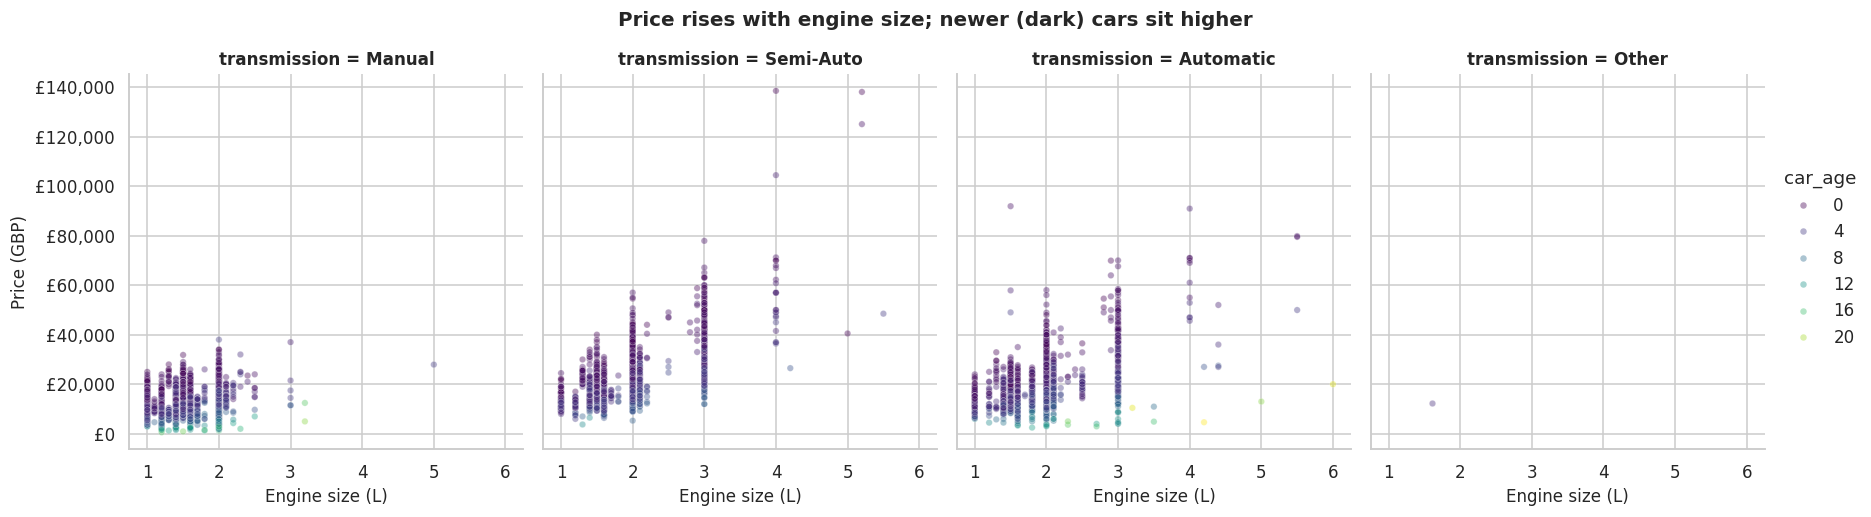

In [20]:
# multivariate view: engineSize -> price, coloured by age, faceted by transmission
g = sns.relplot(data=df.sample(8000, random_state=1),
                x="engineSize", y="price", hue="car_age",
                col="transmission", palette="viridis",
                alpha=0.4, s=18, height=4.5, aspect=0.9)
g.set_axis_labels("Engine size (L)", GBP)
g.set_titles("transmission = {col_name}")
g.figure.suptitle("Price rises with engine size; newer (dark) cars sit higher",
                  y=1.04, fontsize=13, fontweight="bold")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.show()


> **洞察小結**：綜合來看，價格的最強訊號依序是 **引擎排量（+）> 車齡/年份（−/＋）> 里程（−）> 油耗（−）**。分面圖進一步顯示：在同一變速箱類別內，價格隨排量上升、且新車（深色）整體高於舊車——三個維度疊加出清楚的定價結構。


## 11. 結論、限制與後續

### 回應五個子問題（Storytelling 總結）
1. **品牌溢價**：存在明確分層（德系豪華 ≈ 平價品牌的 2 倍），但部分來自規格組成而非純品牌。
2. **折舊曲線**：車齡與里程驅動的折舊真實、陡峭且**非線性**，新車前期掉價最快。
3. **規格驅動**：**引擎排量是最強正向訊號**；mpg 的負相關是混淆效應，非因果。
4. **市場演變**：柴油退潮、汽油與 Hybrid 上升，年份夾帶車種世代效應。
5. **綜合畫像**：排量 → 車齡 → 里程 → 油耗 構成主要定價軸，多維疊加結構清晰。

### 給經銷商的初步建議
- 定價先錨定 **品牌 × 車齡 × 排量** 三主軸，再以里程微調。
- 切勿用「高 mpg」當賣點抬價——市場資料顯示高 mpg 車反而偏平價。
- 留意燃料結構轉變，柴油車的議價空間可能持續收窄。

### 限制（誠實揭露）
- **觀測資料、非因果**：所有相關係數僅描述關聯，不能解讀為因果。
- **快照年假設**：`car_age` 以 2020 為基準，若資料蒐集年不同需校正。
- **混淆與共線性**：品牌、排量、車齡、變速箱彼此交纏，單變量關聯會被混淆。
- **上架價非成交價**：`price` 是掛牌價，未必等於最終成交價。

### 後續（銜接 Final Project 建模）
1. **特徵工程**：類別變數編碼、車齡/里程交互項、品牌目標編碼。
2. **建模**：以對數價格為目標，用線性迴歸建立可解釋基準，再上樹模型（隨機森林 / 梯度提升）比較。
3. **效應分離**：用多元迴歸或 SHAP 在控制其他變數後估計「純品牌效應」，回答第 6 章未解的問題。

---

### 資料來源附註
本分析使用 `car_data/` 下 9 個品牌乾淨檔。`cclass.csv` / `focus.csv`（Mercedes / Ford 子集）因會重複計算且 schema 不一致而排除；`unclean *.csv` 為課程資料清理練習素材，不屬本市場分析範圍。視覺化全程採 **matplotlib + seaborn**；圖內文字使用英文（含單位）以避免中文字型缺字，敘事採繁體中文。
